In [1]:
# Make sure TensorFlow 2.x is used
import tensorflow as tf
print(tf.__version__)  # should be >= 2.8


2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_dir = "/content/drive/MyDrive/chest_xray/train"
val_dir   = "/content/drive/MyDrive/chest_xray/val"
test_dir  = "/content/drive/MyDrive/chest_xray/test"


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [2]:
# Define image size and batch size
IMG_SIZE = 224
BATCH_SIZE = 32


In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Define again in case Step 1 was skipped
IMG_SIZE = 224

# Load ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1088s 7s/step - accuracy: 0.6722 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.8402
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 715ms/step - accuracy: 0.7450 - loss: 0.5641 - val_accuracy: 0.5000 - val_loss: 0.8062
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 721ms/step - accuracy: 0.7453 - loss: 0.5392 - val_accuracy: 0.5000 - val_loss: 0.7479
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 139s 703ms/step - accuracy: 0.7374 - loss: 0.5330 - val_accuracy: 0.5000 - val_loss: 0.7776
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 723ms/step - accuracy: 0.7623 - loss: 0.5016 - val_accuracy: 0.5000 - val_loss: 0.7644
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 717ms/step - accuracy: 0.7590 - loss: 0.5028 - val_accuracy: 0.5000 - val_loss: 0.7622
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 721ms/step - accuracy: 0.7560 - loss: 0.4955 - val_accuracy: 0.5000 - val_loss: 0.7833
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 712ms/step - accuracy: 0.7623 - l

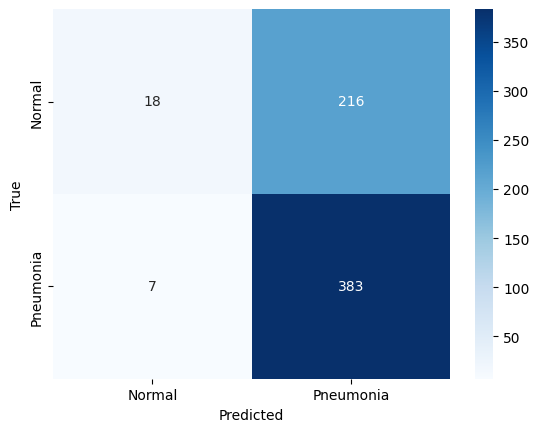

In [5]:
# ------------------ STEP 0: Setup ------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define constants
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

# ------------------ STEP 1: Paths ------------------
train_dir = "/content/drive/MyDrive/chest_xray/train"
val_dir   = "/content/drive/MyDrive/chest_xray/val"
test_dir  = "/content/drive/MyDrive/chest_xray/test"

# ------------------ STEP 2: Data Generators ------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ------------------ STEP 3: Build ResNet50 ------------------
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ------------------ STEP 4: Train ------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

# ------------------ STEP 5: Evaluate ------------------
loss, acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

# ------------------ STEP 6: Confusion Matrix ------------------
y_pred = model.predict(test_gen)
y_pred = (y_pred > 0.5).astype(int).ravel()

print(classification_report(test_gen.classes, y_pred, target_names=['Normal','Pneumonia']))

cm = confusion_matrix(test_gen.classes, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_resnet50.h5",          # filename
    monitor="val_accuracy",      # you can also use "val_loss"
    save_best_only=True,         # only save best weights
    mode="max",                  # "min" if monitoring loss
    verbose=1
)

# Optional: stop early if no improvement
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,                  # wait 5 epochs before stopping
    mode="max",
    restore_best_weights=True,
    verbose=1
)


In [11]:
EPOCHS = 20

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.7626 - loss: 0.4710
Epoch 1: val_accuracy did not improve from 0.56250
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 708ms/step - accuracy: 0.7626 - loss: 0.4709 - val_accuracy: 0.5625 - val_loss: 0.7591
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.7815 - loss: 0.4557
Epoch 2: val_accuracy did not improve from 0.56250
163/163 ━━━━━━━━━━━━━━━━━━━━ 120s 734ms/step - accuracy: 0.7815 - loss: 0.4557 - val_accuracy: 0.5625 - val_loss: 0.7456
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.7646 - loss: 0.4662
Epoch 3: val_accuracy did not improve from 0.56250
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 755ms/step - accuracy: 0.7646 - loss: 0.4662 - val_accuracy: 0.5000 - val_loss: 0.8745
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.7787 - loss: 0.4539
Epoch 4: val_accuracy did not improve from 0.56250
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 744ms/step - accuracy: 0.7787 - loss: 0.4539 - 

In [13]:
from tensorflow.keras.models import load_model

best_model = load_model("best_resnet50.h5")

# Evaluate on test data
loss, acc = best_model.evaluate(test_gen)
print(f"✅ Best Model Test Accuracy: {acc*100:.2f}%")


20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 403ms/step - accuracy: 0.3643 - loss: 0.8559
✅ Best Model Test Accuracy: 66.19%


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 326ms/step
              precision    recall  f1-score   support

      Normal       0.71      0.15      0.25       234
   Pneumonia       0.65      0.96      0.78       390

    accuracy                           0.66       624
   macro avg       0.68      0.56      0.51       624
weighted avg       0.68      0.66      0.58       624



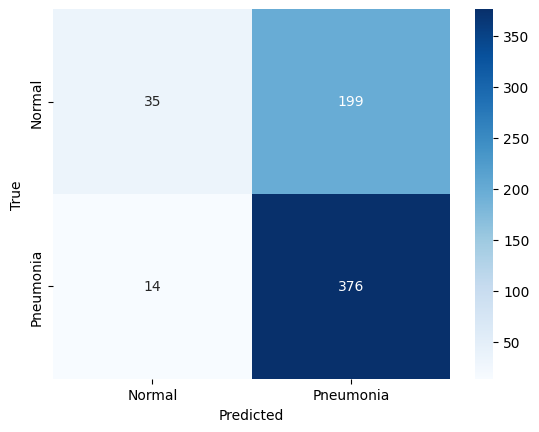

In [14]:
y_pred = model.predict(test_gen)
y_pred = (y_pred > 0.5).astype(int).ravel()

print(classification_report(test_gen.classes, y_pred, target_names=['Normal','Pneumonia']))

cm = confusion_matrix(test_gen.classes, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [17]:
import tensorflow, numpy, cv2, matplotlib
print("TensorFlow:", tensorflow.__version__)
print("NumPy:", numpy.__version__)
print("OpenCV:", cv2.__version__)


TensorFlow: 2.19.0
NumPy: 2.0.2
OpenCV: 4.12.0


In [18]:
!pip install opencv-python-headless


In [19]:
# ---------------- STEP 0: Basic imports & settings ----------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2

# Reproducibility (best effort)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------- STEP 1: Mount Google Drive ----------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------- STEP 2: Locate the dataset folder (auto-detect common locations) ----------------
candidates = [
    "/content/drive/MyDrive/chest_xray",
    "/content/drive/MyDrive/Chest X-Ray/chest_xray",
    "/content/drive/MyDrive/Colab Notebooks/chest_xray",
    "/content/chest_xray",
    "/content/drive/MyDrive/chestxray"
]

base_dir = None
for p in candidates:
    if os.path.isdir(os.path.join(p, "train")) and os.path.isdir(os.path.join(p, "test")):
        base_dir = p
        break

if base_dir is None:
    raise FileNotFoundError("Could not find dataset folder automatically. Set `base_dir` to your chest_xray folder path manually.")
else:
    print("Using dataset folder:", base_dir)

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# quick sanity check
print("Train subfolders:", os.listdir(train_dir)[:10])
print("Val subfolders  :", os.listdir(val_dir)[:10])
print("Test subfolders :", os.listdir(test_dir)[:10])

# ---------------- STEP 3: Hyperparams & DataGenerators ----------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50   # your requested 50 epochs

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.12,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Note: color_mode='rgb' ensures 3-channel input for ResNet50 even if images are grayscale.
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    color_mode='rgb',
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

test_gen = val_test_datagen.flow_from_directory(
    te


SyntaxError: incomplete input (ipython-input-1428537557.py, line 93)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.6341 - loss: 0.7004
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /content/drive/MyDrive/best_resnet50_chestxray.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 747ms/step - accuracy: 0.6343 - loss: 0.7002 - val_accuracy: 0.5000 - val_loss: 0.8900 - learning_rate: 1.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.6854 - loss: 0.6580
Epoch 2: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 721ms/step - accuracy: 0.6854 - loss: 0.6579 - val_accuracy: 0.5000 - val_loss: 0.8586 - learning_rate: 1.0000e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.7166 - loss: 0.6237
Epoch 3: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 728ms/step - accuracy: 0.7166 - loss: 0.6237 - val_accuracy: 0.5000 - val_loss: 0.8380 - learning_rate: 1.0000e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.7195 - loss: 0.6089
Epoch 4: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 723ms/step - accuracy: 0.7196 - loss: 0.6089 - val_accuracy: 0.5000 - val_loss: 0.8194 - learning_rate

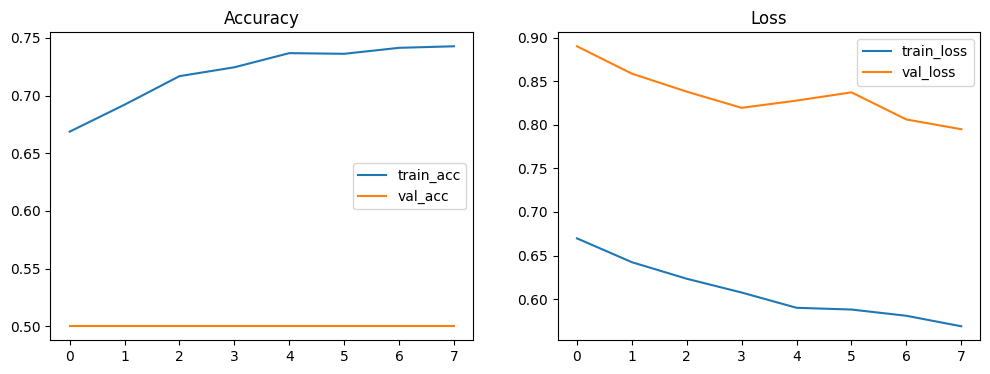

Loaded best model from /content/drive/MyDrive/best_resnet50_chestxray.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step - accuracy: 0.2984 - loss: 1.1614
✅ Test Loss: 0.7342  Test Accuracy: 62.50%
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 457ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


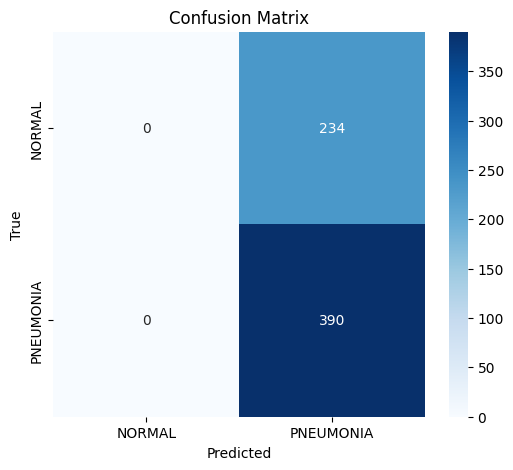

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


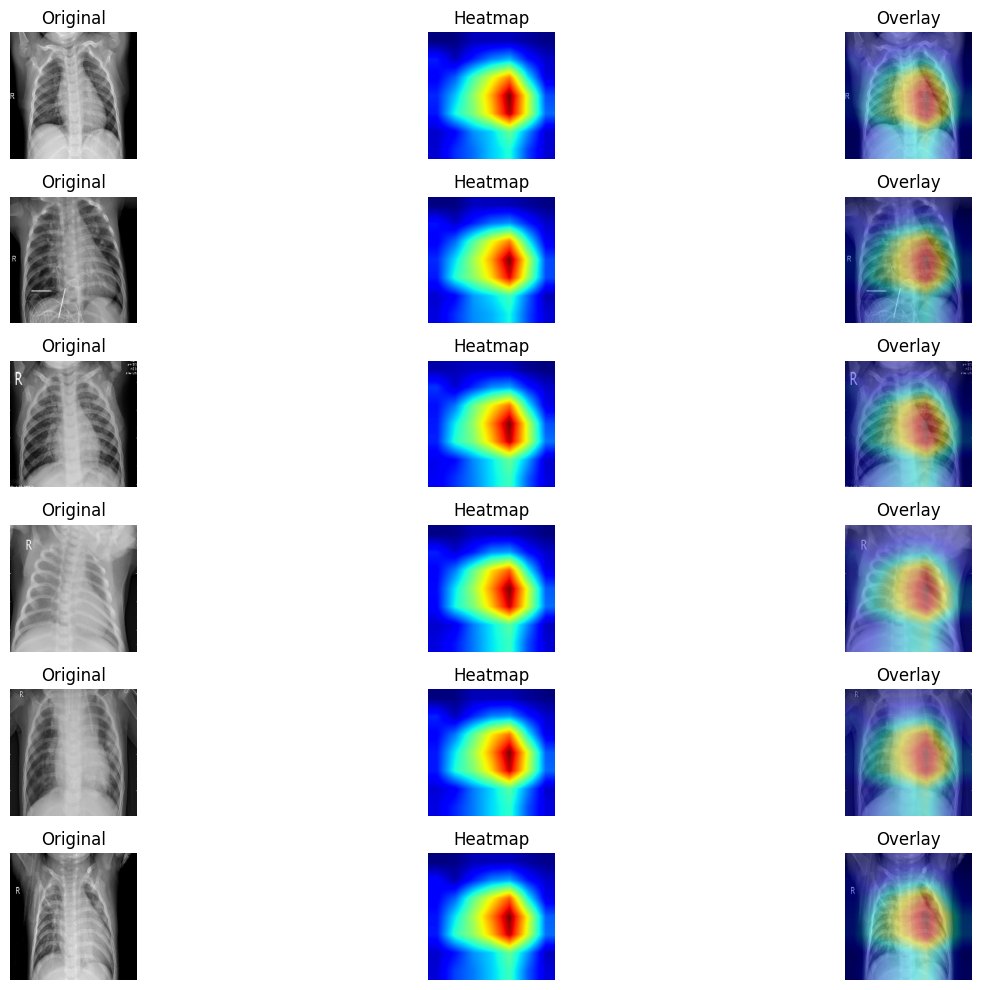

In [20]:
# ---------------- STEP 0: Setup ----------------
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------- STEP 1: Mount Google Drive ----------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------- STEP 2: Dataset Paths ----------------
base_dir = "/content/drive/MyDrive/chest_xray"
train_dir = base_dir + "/train"
val_dir   = base_dir + "/val"
test_dir  = base_dir + "/test"

# ---------------- STEP 3: Hyperparams & Data Generators ----------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.12,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    color_mode='rgb',
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

class_indices = train_gen.class_indices
print("Class indices:", class_indices)
inv_class_indices = {v:k for k,v in class_indices.items()}

# ---------------- STEP 4: Build ResNet-50 ----------------
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

# ---------------- STEP 5: Callbacks ----------------
checkpoint_path = "/content/drive/MyDrive/best_resnet50_chestxray.h5"
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

earlystop = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=False,
    verbose=1,
    mode="max"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    mode="min",
    min_lr=1e-7
)

callbacks = [checkpoint, earlystop, reduce_lr]

# ---------------- STEP 6: Train ----------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ---------------- STEP 7: Plot Training Curves ----------------
def plot_history(hist):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='train_acc')
    plt.plot(hist.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='train_loss')
    plt.plot(hist.history['val_loss'], label='val_loss')
    plt.title('Loss'); plt.legend()
    plt.show()

plot_history(history)

# ---------------- STEP 8: Load Best Model ----------------
best_model = load_model(checkpoint_path)
print("Loaded best model from", checkpoint_path)

# ---------------- STEP 9: Evaluate on Test Set ----------------
loss, acc = best_model.evaluate(test_gen, verbose=1)
print(f"✅ Test Loss: {loss:.4f}  Test Accuracy: {acc*100:.2f}%")

preds = best_model.predict(test_gen, verbose=1)
y_pred = (preds > 0.5).astype(int).ravel()
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[inv_class_indices[0], inv_class_indices[1]]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[inv_class_indices[0], inv_class_indices[1]],
            yticklabels=[inv_class_indices[0], inv_class_indices[1]])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------------- STEP 10: Grad-CAM ----------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap_on_img(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    overlayed = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB), heatmap_resized, cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB)

# Show Grad-CAM for 6 random test images
num_to_show = 6
indices = np.random.choice(len(test_gen.filepaths), size=num_to_show, replace=False)

plt.figure(figsize=(15,10))
for i, idx in enumerate(indices):
    img_path = test_gen.filepaths[idx]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = tf.keras.preprocessing.image.img_to_array(img)
    img_arr = np.expand_dims(img_arr, axis=0) / 255.0

    heatmap = make_gradcam_heatmap(img_arr, best_model)
    orig, heatmap_resized, overlay = overlay_heatmap_on_img(img_path, heatmap)

    plt.subplot(num_to_show, 3, 3*i+1); plt.imshow(orig); plt.title("Original"); plt.axis('off')
    plt.subplot(num_to_show, 3, 3*i+2); plt.imshow(heatmap_resized, cmap='jet'); plt.title("Heatmap"); plt.axis('off')
    plt.subplot(num_to_show, 3, 3*i+3); plt.imshow(overlay); plt.title("Overlay"); plt.axis('off')

plt.tight_layout()
plt.show()
